# Multiobjective optimization --  3 cost terms

In [1]:
import sys
print(f"Python version: {sys.version}")
import json
import logging
import csv
import gzip
import re
import pandas as pd
import numpy as np
from functools import reduce
from pyspark.sql.types import StringType,DecimalType,DoubleType,IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.feature import VectorAssembler, Bucketizer
import matplotlib.pyplot as plt
import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark.sql import SparkSession,Row
from pyspark import SparkConf
import plotly.express as px
import plotly.graph_objects as go
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# -----------------------------------------------------------------------------
# INITIALIZE LOGGING
# -----------------------------------------------------------------------------
f = '%(asctime)-15s %(levelname)-8s %(message)s'
logger = logging.getLogger(__name__)
logger.setLevel("DEBUG")
logging.basicConfig(format=f)


from IPython.core.magic import register_cell_magic

# -----------------------------------------------------------------------------
# start_spark
# -----------------------------------------------------------------------------
def start_spark(
    driver_memory="100g",
    storage_fraction=0.5,
    num_nodes=10,
):
    """Initialize spark

    Arguments:
        driver_memory: Maximum heap size for the Spark driver Java
            virtual machine.
        storage_fraction: Controls what portion of Spark's unified
            memory is reserved for storage (i.e., caching/persisting data
            and broadcast variables), as a fraction of the total
            execution + storage memory pool.
            If you cache/persist a lot of data, and you're evicting
            data too early, you might increase this value (e.g. 0.6 or 0.7).
            Conversely, if your job is shuffle-heavy and fails due to
            memory pressure, you might decrease it (e.g. 0.3).
        num_nodes: How many concurrent threads to use while running
            in "local mode" (i.e. in a single machine instead of a cluster).
            Use '*' to use all cores, or an integer > 0 for a specific
            number of threads.
    """

    conf = SparkConf().setAppName("My_Application")
    conf.set("spark.driver.memory", driver_memory)
    conf.set("spark.memory.storageFraction", str(storage_fraction))
    conf.setMaster(f"local[{num_nodes}]")

    spark = SparkSession.builder.config(conf=conf).getOrCreate()
    spark.sparkContext.setLogLevel('WARN')

    return spark


Python version: 3.11.0 (main, Jun 13 2025, 14:48:45) [Clang 16.0.0 (clang-1600.0.26.6)]


In [2]:

spark = start_spark(num_nodes=10)
#spark.stop()

  
@register_cell_magic
def spark_sql(line, cell):
    result = spark.sql(cell)
    result.show(n=1000)
  

# -- READ ENROLLMENT AND DATA TABLES
enrollment_file = f"/Users/Charles/DATA/ckd/ckd_enrollment"
logger.info(f">>> Reading enrollment file: {enrollment_file}")
df_enrollment = spark.read.format("parquet").load(enrollment_file)
df_enrollment.createOrReplaceTempView('enrollment')
logger.info(f">>> ENROLLMENT has {df_enrollment.count():,} rows")
logger.info(f">>> ENROLLMENT has {df_enrollment.select('ENROLID').distinct().count():,} unique enrollees")

claims_file = f"/Users/Charles/DATA/ckd/ckd_claims"
logger.info(f">>> Reading claims file: {claims_file}")
df_claims = spark.read.format("parquet").load(claims_file)
df_claims.createOrReplaceTempView('claims')
logger.info(f">>> CLAIMS has {df_claims.count():,} rows")
logger.info(f">>> CLAIMS has {df_claims.select('ENROLID').distinct().count():,} unique enrollees")

# -- NOTE: with the "createOrReplaceTempView" we define a view of these
# -- tables, so we can use them in SQL queries.

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/02 10:22:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
2025-12-02 10:22:03,955 INFO     >>> Reading enrollment file: /Users/Charles/DATA/ckd/ckd_enrollment
25/12/02 10:22:04 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
2025-12-02 10:22:05,533 INFO     >>> ENROLLMENT has 2,586,930 rows
2025-12-02 10:22:07,102 INFO     >>> ENROLLMENT has 862,310 unique enrollees    
2025-12-02 10:22:07,102 INFO     >>> Reading claims file: /Users/Charles/DATA/ckd/ckd_claims
2025-12-02 10:22:07,830 INFO     >>> CLAIMS has 253,070,875 rows
2025-12-02 10:22:14,352 INFO     >>> CLAIMS has 86

# Load Data

In [3]:
df_2018 = spark.read.format("parquet").load( "0917_2017_18_with_2017_cost.parquet")
df_og = df_2018.toPandas()
df_og.shape,df_og.columns

((33542, 95),
 Index(['ENROLID', 'annual_cost_2017', 'highcost_gt_50000_2017',
        'highcost_gt_75000_2017', 'highcost_gt_100000_2017',
        'highcost_gt_200000_2017', 'highcost_gt_300000_2017',
        'highcost_gt_400000_2017', 'highcost_gt_500000_2017', 'INCOME_LEVEL',
        'annual_cost_2018_deflated', 'highcost_gt_50000', 'highcost_gt_75000',
        'highcost_gt_100000', 'highcost_gt_200000', 'highcost_gt_300000',
        'highcost_gt_400000', 'highcost_gt_500000', 'AGEGRP', 'SEX', 'REGION',
        'has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia',
        'has_Hyperlipidemia', 'has_Acute_Kidney_Failure',
        'has_Hyperparathyroidism', 'has_Kidney_Transplant',
        'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy',
        'has_Hypothyroidism', 'has_Sleep_Apnea', 'stage_2017', 'util_2017',
        'Antihyperlipidemic Drugs, NEC (THRCLS_53)',
        'Cardiac, Beta Blockers (THRCLS_51)',
        'Cardiac, Calcium Channel (THRCLS_52)',
        'Psychot

# Feature groups, define high cost and train-test-split

In [4]:
import importlib
import model_pipeline
importlib.reload(model_pipeline)
BIN_FLAG_COLUMNS = model_pipeline.get_bin_flag_columns(df_og) +['lab_monitoring_adherent','nephrology_consult_adherent','early_nephrology_referral']
STAGE_COLUMNS = [col for col in df_og.columns if "stage" in col.lower()]
#["stage_2017",'2017Q1_max_ckd_stage','2017Q2_max_ckd_stage', '2017Q3_max_ckd_stage','2017Q4_max_ckd_stage']
CAT_COLUMNS = df_og.select_dtypes(include=["object","category"]).columns.tolist()
TRUE_NUM_COLUMNS = model_pipeline.get_true_num_columns(df_og,CAT_COLUMNS)+[ 'util_2017', 'total_increasing_quarters_2017'
, 'total_lab_tests', 'ckd_visit_count', 'quarters_with_labs', 'nephrology_visit_count', 'days_to_nephrology','MEDIAN_INCOME']
COST_COLUMNS = [col for col in df_og.columns if 
            "cost" in col.lower() or 
             "quarterly" in col.lower()  or "increasing" in col.lower()
             ]
UTILIZATION_COLUMNS = [col for col in df_og.columns if "claims" not in col.lower() ] + ['util_2017']
print("categorical cols: ", CAT_COLUMNS)
print("stage cols: ", STAGE_COLUMNS)
print(COST_COLUMNS)
leftover_cols = [
    c for c in df_og.columns 
    if c not in CAT_COLUMNS and c not in TRUE_NUM_COLUMNS and c not in STAGE_COLUMNS and c not in BIN_FLAG_COLUMNS 
]

print(f"Number of leftover columns: {len(leftover_cols)}")
print(leftover_cols, df_og.shape)  # preview first 50

def make_cost_stratum_3class(df):
    # Default to low-cost (class 0)
    cost_stratum = pd.Series(0, index=df.index)
    # Moderate (class 1): 50k+ to 100k
   # cost_stratum[(df['annual_cost_2017'] <= 10000)] = 1
   # cost_stratum[(df['annual_cost_2017'] > 10000) & (df['annual_cost_2017'] <= 20000)] = 2
   # cost_stratum[(df['annual_cost_2017'] > 20000) & (df['annual_cost_2017'] <= 30000)] = 3
    #cost_stratum[(df['annual_cost_2017'] > 30000) & (df['annual_cost_2017'] <= 40000)] = 4
   #cost_stratum[(df['annual_cost_2017'] > 40000) & (df['annual_cost_2017'] <= 50000)] = 5
    cost_stratum[(df['highcost_gt_50000'] == 1) & (df['highcost_gt_100000'] == 0)] = 1
    # Emergent high cost (class 2): 100k to 200k
    cost_stratum[(df['highcost_gt_100000'] == 1) & (df['highcost_gt_200000'] == 0)] = 2
    # High cost (class 2): 200k+
    cost_stratum[df['highcost_gt_200000'] == 1] = 3
    return cost_stratum

# Add the new column to your data
df_og['cost_stratum_2018'] = make_cost_stratum_3class(df_og)
print(df_og["cost_stratum_2018"].value_counts(dropna=False))

cutoff_columns = [col for col in df_og.columns if col.startswith('highcost_gt_')]

feature_cols = [c for c in df_og.columns
              if c not in  (['annual_cost_2017','annual_cost_2018_deflated',"ENROLID", "cost_stratum_2018"] 
              + cutoff_columns)]    # keep only predictors excl. cost of 2018 and cutoff of 2017
numeric_cols = df_og[feature_cols + ["cost_stratum_2018"]].select_dtypes(include=["number"]).columns
corrs = df_og[numeric_cols].corr()["cost_stratum_2018"].abs().sort_values(ascending=False)
# Columns to drop
high_corr_cols = corrs[corrs > 0.5].index.tolist()
# Remove the target column itself, if present
high_corr_cols = [col for col in high_corr_cols if col != "cost_stratum_2018"]
# Final filtered feature set
feature_cols = [col for col in feature_cols if col not in high_corr_cols]
print("High corr features dropped from prediction columns: ",high_corr_cols)
target_col = "highcost_gt_200000"

categorical cols:  ['ENROLID', 'INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
stage cols:  ['stage_2017', '2017Q1_max_ckd_stage', '2017Q2_max_ckd_stage', '2017Q3_max_ckd_stage', '2017Q4_max_ckd_stage']
['annual_cost_2017', 'highcost_gt_50000_2017', 'highcost_gt_75000_2017', 'highcost_gt_100000_2017', 'highcost_gt_200000_2017', 'highcost_gt_300000_2017', 'highcost_gt_400000_2017', 'highcost_gt_500000_2017', 'annual_cost_2018_deflated', 'highcost_gt_50000', 'highcost_gt_75000', 'highcost_gt_100000', 'highcost_gt_200000', 'highcost_gt_300000', 'highcost_gt_400000', 'highcost_gt_500000', '2017Q1_ckd_cost', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4

In [5]:
split_seed = 42
train_ids, test_ids,train_pd,test_pd = model_pipeline.train_test_split_enrol(df_og,
    target_col = "cost_stratum_2018",test_size=0.3,verbose=False,random_state=split_seed)
print(train_pd.shape,test_pd.shape)
print("Feature cols:", len(feature_cols))

val_ids, test_ids,val_pd,test_pd = model_pipeline.train_test_split_enrol(test_pd, target_col = "cost_stratum_2018",test_size=0.5,verbose=False)
X_test = test_pd[feature_cols]
y_test = test_pd[target_col]
X_val = val_pd[feature_cols]
y_val = val_pd[target_col]

(23479, 96) (10063, 96)
Feature cols: 78


# Global undersampling using Bilevel Opt.

In [6]:
import balancing_functions.bilevel_sampler
importlib.reload(balancing_functions.bilevel_sampler)
from balancing_functions.bilevel_sampler import BilevelResampler

In [7]:

matcher = BilevelResampler(
    matching_method="ortools",
    random_state=42,
    binary_group=target_col,
    uid_col="ENROLID",
)
maj = train_pd[train_pd[target_col] == 0].copy()
minr = train_pd[train_pd[target_col] == 1].copy()

# Run bilevel undersampling
#undersampled_training_data = matcher.bilevel_undersample(df_cases=minr, df_controls=maj, exclude_cols_matching=["cost_stratum_2018"]+ COST_COLUMNS,
 #   K_factor=10.0,  final_ratio=1.0, top_k_factor=1000, verbose=True,)
undersampled_training_data = matcher.unified_undersample_wrapper_diverse(df_cases=minr, 
        df_controls=maj, exclude_cols_matching=["cost_stratum_2018"],#+ COST_COLUMNS, 
        final_ratio=1.0,
        w=0.5,
        top_k_case_ctrl=20,
       # top_k_ctrl_ctrl=20,
        K_factor=3.0,        # INNER PRUNING size
        verbose=True)

print("Final shape:", undersampled_training_data.shape)
print(undersampled_training_data["cost_stratum_2018"].value_counts())
"""[Objective decomposition]
  term_cases     = 9413.6878
  term_coverage  = 4667.2291
  weighted_obj   = 2373.2293
Final shape: (1320, 96)
cost_stratum_2018
3    660
0    487
1     96
2     77
"""

AttributeError: 'BilevelResampler' object has no attribute 'unified_undersample_wrapper_diverse'

In [ ]:
import os, pickle

import model_IAI
importlib.reload(model_IAI)
from model_IAI import evaluate_binary_oct, finetune_oct

minbuckets_M2 = [50, 100, 120, 150]
cps_M2 = [0.00001, 5e-5, 0.0001, 5e-3]
depths_M2 = [5, 7]

# -----------------------
# Build matcher once
# -----------------------
matcher = BilevelResampler(
    matching_method="ortools",
    random_state=42,
    binary_group=target_col,
    uid_col="ENROLID",
)

# Separate majority/minority
maj = train_pd[train_pd[target_col] == 0].copy()
# OPTIONAL: restrict to stratum 0
# maj = maj[maj["cost_stratum_2018"] == 0]

minr = train_pd[train_pd[target_col] == 1].copy()


results_dir = "./w_sweep_results_pushpull_ratio2"
os.makedirs(results_dir, exist_ok=True)
metrics_master_path = f"{results_dir}/metrics_master.csv"

all_metrics = []

w_values = np.linspace(0.0, 1.0, 11)

for w in w_values:
    print("\n====================================")
    print(f"  Running unified MILP sampling w={w:.2f}")
    print("====================================\n")

    undersampled_training_data = matcher.biobjective_push_pull_wrapper(
        df_cases=minr,
        df_controls=maj,
        exclude_cols_matching=["cost_stratum_2018"] + COST_COLUMNS,
        final_ratio=2.0,
        w=w,
        top_k_case_ctrl=20,
        #top_k_ctrl_ctrl=20,
        K_factor=3.0,
        verbose=True
    )
    # Save undersampled dataset
    save_path = f"{results_dir}/undersampled_w_{w:.2f}.csv"
    undersampled_training_data.to_csv(save_path, index=False)

    # Train model
    balanced_model, balanced_params, _, preprocessor, feature_names = finetune_oct(
        X_train=undersampled_training_data[feature_cols],
        y_train=undersampled_training_data[target_col],
        X_val=X_val,
        y_val=y_val,
        categorical_cols=CAT_COLUMNS,
        numeric_cols=TRUE_NUM_COLUMNS,
        depths=depths_M2,
        minbuckets=minbuckets_M2,
        cps=cps_M2
    )

    # Evaluate
    metrics = evaluate_binary_oct(
        balanced_model,
        X_test,
        y_test,
        preprocessor,
        feature_names
    )

    row = metrics.copy()
    row["w"] = w

    # Append to master table
    pd.DataFrame([row]).to_csv(metrics_master_path, mode='a',
                               header=not os.path.exists(metrics_master_path),
                               index=False)

    # Save full metrics dict with leaf-level metrics
    with open(f"{results_dir}/metrics_full_w_{w:.2f}.pkl", "wb") as f:
        pickle.dump(metrics, f)

    all_metrics.append(row)



  Running unified MILP sampling w=0.00

>>> Distance computation will use 42 features
5 Categorical features (one-hot encoded): ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
12 Numeric features (normalized): ['stage_2017', 'util_2017', '2017Q1_ckd_claims', '2017Q1_max_ckd_stage', '2017Q2_ckd_claims', '2017Q2_max_ckd_stage', '2017Q3_ckd_claims', '2017Q3_max_ckd_stage', '2017Q4_ckd_claims', '2017Q4_max_ckd_stage', 'total_lab_tests', 'nephrology_visit_count']
25 Binary features (unchanged): ['has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia', 'has_Hyperlipidemia', 'has_Acute_Kidney_Failure', 'has_Hyperparathyroidism', 'has_Kidney_Transplant', 'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy', 'has_Hypothyroidism', 'has_Sleep_Apnea', 'Antihyperlipidemic Drugs, NEC (THRCLS_53)', 'Cardiac, Beta Blockers (THRCLS_51)', 'Cardiac, Calcium Channel (THRCLS_52)', 'Psychother, Antidepressants (THRCLS_69)', 'Cardiac Drugs, NEC (THRCLS_46)', 'Cardiac, ACE Inhibit

# DoubleFacilitySampler

In [9]:
import balancing_functions.double_facility_scaled_sampler
importlib.reload(balancing_functions.double_facility_scaled_sampler)
from balancing_functions.double_facility_scaled_sampler import DoubleFacilitySampler 

import os, pickle
minbuckets_M2 = [50, 100, 120, 150]
cps_M2 = [0.00001, 5e-5, 0.0001, 5e-3]
depths_M2 = [5, 7]


In [ ]:
matcher = DoubleFacilitySampler(
    matching_method="ortools",
    random_state=42,
    binary_group=target_col,
    uid_col="ENROLID",
)
maj = train_pd[train_pd[target_col] == 0].copy()
minr = train_pd[train_pd[target_col] == 1].copy()

results_dir = "./w_sweep_results_doublefac_normalized_"
os.makedirs(results_dir, exist_ok=True)
metrics_master_path = f"{results_dir}/metrics_master.csv"

w_values = np.linspace(0.0, 1.0, 11)
records = []  

for w in w_values:
    print("="*40)
    print(f" Running double-facility sampling w={w:.2f}")
    print("="*40)

    undersampled_training_data, rec = matcher.biobjective_double_facility_wrapper(
        df_cases=minr,
        df_controls=maj,
        exclude_cols_matching=["cost_stratum_2018"] + COST_COLUMNS,
        final_ratio=1.0,
        w=w,
        top_k_case_ctrl=50,
        top_k_ctrl_ctrl=50,
        K_factor=6.0,
        stratified=False,
        verbose=True,
    )
    records.append(rec)
all_records = pd.DataFrame(records)



 Running double-facility sampling w=0.00
>>> Distance computation will use 42 features
5 Categorical features (one-hot encoded): ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
12 Numeric features (normalized): ['stage_2017', 'util_2017', '2017Q1_ckd_claims', '2017Q1_max_ckd_stage', '2017Q2_ckd_claims', '2017Q2_max_ckd_stage', '2017Q3_ckd_claims', '2017Q3_max_ckd_stage', '2017Q4_ckd_claims', '2017Q4_max_ckd_stage', 'total_lab_tests', 'nephrology_visit_count']
25 Binary features (unchanged): ['has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia', 'has_Hyperlipidemia', 'has_Acute_Kidney_Failure', 'has_Hyperparathyroidism', 'has_Kidney_Transplant', 'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy', 'has_Hypothyroidism', 'has_Sleep_Apnea', 'Antihyperlipidemic Drugs, NEC (THRCLS_53)', 'Cardiac, Beta Blockers (THRCLS_51)', 'Cardiac, Calcium Channel (THRCLS_52)', 'Psychother, Antidepressants (THRCLS_69)', 'Cardiac Drugs, NEC (THRCLS_46)', 'Cardiac, ACE Inhibit

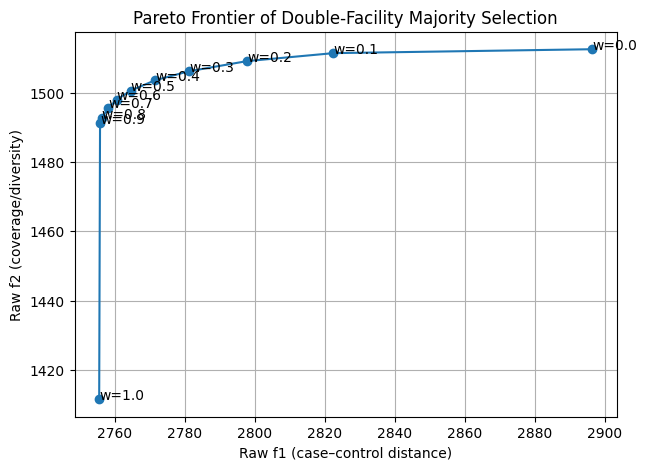

In [8]:
plt.figure(figsize=(7,5))
plt.plot(all_records["f1"], all_records["f2"], marker="o", linestyle="-")

for i,row in all_records.iterrows():
    plt.text(row["f1"], row["f2"], f"w={row['w']:.1f}")

plt.xlabel("Raw f1 (case–control distance)")
plt.ylabel("Raw f2 (coverage/diversity)")
plt.title("Pareto Frontier of Double-Facility Majority Selection")
plt.grid(True)
plt.show()

In [9]:
split_seed = 42

In [10]:
import model_IAI
importlib.reload(model_IAI)
from model_IAI import evaluate_binary_oct, finetune_oct

results_dir = "./w_sweep_results_doublefac_normalized"
os.makedirs(results_dir, exist_ok=True)
metrics_master_path = f"{results_dir}/metrics_master.csv"

w_values = np.linspace(0.0, 1.0, 11)

for w in w_values:
    print("="*40)
    print(f"Loading double-facility sampling w={w:.2f}")
    print("="*40)
    save_path = f"{results_dir}/undersampled_w_{w:.2f}.csv"
    undersampled_training_data = pd.read_csv(save_path)

    print("Final shape at w",w, " ",undersampled_training_data.shape)
    print(undersampled_training_data["cost_stratum_2018"].value_counts())
    balanced_model, balanced_params, _, preprocessor, feature_names = finetune_oct(
        X_train=undersampled_training_data[feature_cols],
        y_train=undersampled_training_data[target_col],
        X_val=X_val,
        y_val=y_val,
        categorical_cols=CAT_COLUMNS,
        numeric_cols=TRUE_NUM_COLUMNS,
        depths=depths_M2,
        minbuckets=minbuckets_M2,
        cps=cps_M2
    )

    metrics = evaluate_binary_oct(
        balanced_model,
        X_test,
        y_test,
        preprocessor,
        feature_names
    )

    row = metrics.copy()
    row["w"] = w

    pd.DataFrame([row]).to_csv(
        metrics_master_path,
        mode='a',
        header=not os.path.exists(metrics_master_path),
        index=False
    )

    with open(f"{results_dir}/metrics_full_w_{w:.2f}_seed{split_seed}.pkl", "wb") as f:
        pickle.dump(metrics, f)


2025-12-01 16:08:07,671 WARNING  Interpretable AI license expires soon: 2025-12-31T00:00:00. If you need to renew, please send us the following machine ID:
da2d87f307115a4389e740fa6b3796f3ca586f217a49634cef5fb2b2945f7cea
/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Loading double-facility sampling w=0.00
Final shape at w 0.0   (1320, 96)
cost_stratum_2018
3    660
0    547
1     60
2     53
Name: count, dtype: int64
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_

┌ Warning: Interpretable AI license expires soon: 2025-12-31T00:00:00. If you need to renew, please send us the following machine ID:
└ da2d87f307115a4389e740fa6b3796f3ca586f217a49634cef5fb2b2945f7cea


Test dataset for OCT application: 5,032 samples


/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


...

[ Warning: The type of y (Any) does not match the original target type (Int64)
/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Test dataset for OCT application: 5,032 samples


/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


✓ Predictions completed
AUC score: 0.839
Sensitivity (Recall): 0.674
Specificity: 0.859
Confusion Matrix:
 [[4200  691]
 [  46   95]]
PR-AUC (Average Precision): 0.137
Per-leaf metrics (top 10):
    leaf_id     n  accuracy  precision  recall        f1
10       22    60  0.200000   0.200000     1.0  0.333333
8        19   112  0.196429   0.196429     1.0  0.328358
11       23   206  0.150485   0.150485     1.0  0.261603
5        15   146  0.089041   0.089041     1.0  0.163522
3         8   136  0.080882   0.080882     1.0  0.149660
7        18   126  0.047619   0.047619     1.0  0.090909
0         3  1996  0.994489   0.000000     0.0  0.000000
1         5   883  0.995470   0.000000     0.0  0.000000
2         7   670  0.980597   0.000000     0.0  0.000000
4        14   161  0.956522   0.000000     0.0  0.000000


[ Warning: The type of y (Any) does not match the original target type (Int64)


## Prebalancing and M1


In [24]:
prebalance_threshold = 0
df_prebalanced = train_pd[train_pd["annual_cost_2017"]>prebalance_threshold]
print(len(train_pd), len(df_prebalanced))

23479 22974


In [15]:
import oct_stratifier
importlib.reload(oct_stratifier)
from oct_stratifier import train_stratifier_oct,train_stratifier_oct_tuned

target = "cost_stratum_2018"
df_prebalanced = train_pd
tune = False
best_params = {'max_depth': 9, 'minbucket': 100, 'cp': 1e-05}
# After your pre-balancing step:
if tune: 
    pipeline_results = train_stratifier_oct_tuned(
        df_prebalanced=df_prebalanced,
        stratification_cols=[col for col in feature_cols if col not in COST_COLUMNS],
        CAT_COLUMNS=CAT_COLUMNS,
        TRUE_NUM_COLUMNS=TRUE_NUM_COLUMNS,
        target=target
    )
else:
    pipeline_results = train_stratifier_oct(
        df_prebalanced=df_prebalanced,
        stratification_cols=[col for col in feature_cols if col not in COST_COLUMNS],
        CAT_COLUMNS=CAT_COLUMNS,
        TRUE_NUM_COLUMNS=TRUE_NUM_COLUMNS,
        target=target,
        best_params =best_params
    )
# Access results:
df_M1 = pipeline_results['df_with_leaves']
model = pipeline_results['model']
preprocessor = pipeline_results['preprocessor']
feature_names = pipeline_results['feature_names']

model


 Training binary OCT M1 on all train data with 23,479 samples
------------------------------------------------------------
Using 42 stratification features for M1
M1 training set target cost_stratum_2018 distribution:
  Class 0: 20,580 samples (87.7%)
  Class 1: 1,260 samples (5.4%)
  Class 2: 979 samples (4.2%)
  Class 3: 660 samples (2.8%)

Training M1 OCT...
Using preset params:  9 100 1e-05
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_claims', '2017Q2_ckd_claims', '2017Q3_ckd_claims', '2017Q4_ckd_claims', 'util_2017', 'total_lab_tests', 'nephrology_visit_count']
✓ OCT training completed successfully
✓ Processed training data shape: (23479, 52)
✓ Feature names: 52
✓ Leaf assignments completed
✓ Number of unique leaves: 10
✓ Number of unique predicted strata: 3
Total unique leaf-class combinations: 10


Fitted OptimalTreeClassifier:
  1) Split: util_2017 < 1.952
    2) Split: 2017Q4_ckd_claims < 0.7193
      3) Predict: 0 (91.66%), [19118,875,563,302], 20858 points, error 0.08342
      4) Split: has_Kidney_Transplant < 0.5
        5) Split: 2017Q4_max_ckd_stage < 4.5
          6) Predict: 0 (70.20%), [834,161,126,67], 1188 points, error 0.298
          7) Split: 2017Q3_ckd_claims < 0.3446
            8) Predict: 0 (51.43%), [54,13,18,20], 105 points, error 0.4857
            9) Predict: 2 (37.88%), [26,19,50,37], 132 points, error 0.6212
        10) Predict: 0 (68.04%), [132,32,21,9], 194 points, error 0.3196
    11) Split: 2017Q4_ckd_claims < 0.8377
      12) Predict: 0 (58.66%), [210,50,66,32], 358 points, error 0.4134
      13) Split: has_Kidney_Transplant < 0.5
        14) Split: 2017Q4_max_ckd_stage < 4.5
          15) Split: util_2017 < 3.121
            16) Predict: 0 (41.53%), [76,42,41,24], 183 points, error 0.5847
            17) Predict: 3 (39.19%), [34,22,34,58], 148 points, error 0.6081
          18) Predict: 3 (51.37%), [29,22,38,94], 183 points, error 0.4863
        19) Predict: 0 (51.54%), [67,24,22,17], 130 points, error 0.4846

### Matching

In [ ]:
from balancing_functions.bilevel_sampler import BilevelResampler

import balancing_functions.optimal_match_lexicographic
importlib.reload(balancing_functions.optimal_match_lexicographic)


<module 'balancing_functions.optimal_match_lexicographic' from '/Users/cat2510/my_projects/balancing_functions/optimal_match_lexicographic.py'>

In [17]:
def create_doublefacility_undersampled_data(
    pipeline_results, 
    target_col, 
    undersampling_ratio=5.0,
    w_fixed=0.2,
    balance_tolerance=2.0,
    verbose=True
):
    """
    Replace BilevelResampler with DoubleFacilitySampler.
    Solve biobjective normalized facility-location at fixed w.

    Parameters
    ----------
    w_fixed : float (in [0,1])
        Fixed weight for f1–f2 normalized objective.
    """

    # ---------------------------------------------------
    # Create sampler
    # ---------------------------------------------------
    matcher = DoubleFacilitySampler(
        matching_method="ortools",
        random_state=42,
        binary_group=target_col,
        uid_col="ENROLID"
    )

    # ---------------------------------------------------
    # Extract dataset
    # ---------------------------------------------------
    df_with_leaves = pipeline_results['df_with_leaves']
    feature_cols = pipeline_results['stratification_cols']

    print(f"=== DOUBLE-FACILITY NORMALIZED UNDERSAMPLING ===")
    print(f"Original dataset: {len(df_with_leaves):,} samples")

    unique_leaves = df_with_leaves['leaf_assignment'].unique()
    print(f"Processing {len(unique_leaves)} OCT leaves...")

    undersampled_parts = []

    # ---------------------------------------------------
    # Iterate each OCT leaf
    # ---------------------------------------------------
    for leaf_id in sorted(unique_leaves):
        leaf_df = df_with_leaves[
            df_with_leaves['leaf_assignment'] == leaf_id
        ].copy()

        # Skip very small leaves
        if len(leaf_df) < 30:
            if verbose:
                print(f"Leaf {leaf_id}: Skipped (too small: {len(leaf_df)} samples)")
            continue

        # Distribution
        class_counts = leaf_df[target_col].value_counts()
        majority_class = class_counts.index[0]
        minority_class = class_counts.index[1]

        n_majority = class_counts[majority_class]
        n_minority = class_counts[minority_class]

        # Check balance tolerance
        if n_majority <= balance_tolerance * n_minority:
            if verbose:
                print(f"Leaf {leaf_id}: Already near-balanced, keeping as-is")
                print(f"  Counts: {n_majority} majority, {n_minority} minority")
            undersampled_parts.append(leaf_df)
            continue

        # Target majority count
        target_majority = n_minority * undersampling_ratio
        if target_majority >= n_majority:
            if verbose:
                print(f"Leaf {leaf_id}: target majority >= existing majority → keeping as-is")
            undersampled_parts.append(leaf_df)
            continue

        majority_df = leaf_df[leaf_df[target_col] == majority_class].copy()
        minority_df = leaf_df[leaf_df[target_col] == minority_class].copy()

        if verbose:
            print(f"\nLeaf {leaf_id}: majority {n_majority} → target {target_majority:.0f}, minority={n_minority}")

        # ---------------------------------------------------
        # Run the double-facility normalized solver
        # ---------------------------------------------------
        try:
            matched_result = matcher.biobjective_double_facility_wrapper(
                df_cases=minority_df,
                df_controls=majority_df,
                exclude_cols_matching=['leaf_assignment', 'cost_stratum'] + COST_COLUMNS,
                final_ratio=undersampling_ratio,
                w=w_fixed,
                top_k_case_ctrl=40,
                top_k_ctrl_ctrl=40,
                K_factor=10.0,
                stratified=False,    # no stratification unless you want it
                verbose=verbose
            )

            undersampled_parts.append(matched_result)

            if verbose:
                final_counts = matched_result[target_col].value_counts()
                print(f"  Result leaf {leaf_id}: {dict(final_counts)}")

        except Exception as e:
            if verbose:
                print(f"  Optimization failed in leaf {leaf_id}: {e}")
                print("  Keeping leaf as-is.")
            undersampled_parts.append(leaf_df)

    # ---------------------------------------------------
    # Combine final subsets
    # ---------------------------------------------------
    if undersampled_parts:
        final_result = pd.concat(undersampled_parts, ignore_index=True)

        print("\n=== FINAL RESULTS ===")
        print(f"Original:     {len(df_with_leaves):,}")
        print(f"Undersampled: {len(final_result):,}")
        print(f"Reduction:    {(1 - len(final_result)/len(df_with_leaves))*100:.1f}%")

        orig = df_with_leaves[target_col].value_counts()
        fin  = final_result[target_col].value_counts()
        print("Class distribution:")
        for cls in orig.index:
            print(f"  Class {cls}: {orig[cls]:,} → {fin.get(cls, 0):,}")

        return final_result
    else:
        print("Warning: No leaves processed successfully.")
        return pd.DataFrame()

undersampled_training_data = create_doublefacility_undersampled_data(
    pipeline_results=pipeline_results,
    target_col=target_col,
    undersampling_ratio=1,   # or 2,3,4
    w_fixed=0.2,
    verbose=True
)

print("Final training data size:", len(undersampled_training_data))


=== DOUBLE-FACILITY NORMALIZED UNDERSAMPLING ===
Original dataset: 23,479 samples
Processing 10 OCT leaves...

Leaf 3: majority 20556 → target 302, minority=302
>>> Distance computation will use 44 features
5 Categorical features (one-hot encoded): ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
14 Numeric features (normalized): ['stage_2017', 'util_2017', '2017Q1_ckd_claims', '2017Q1_max_ckd_stage', '2017Q2_ckd_claims', '2017Q2_max_ckd_stage', '2017Q3_ckd_claims', '2017Q3_max_ckd_stage', '2017Q4_ckd_claims', '2017Q4_max_ckd_stage', 'total_lab_tests', 'nephrology_visit_count', 'cost_stratum_2018', 'predicted_cost_stratum']
25 Binary features (unchanged): ['has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia', 'has_Hyperlipidemia', 'has_Acute_Kidney_Failure', 'has_Hyperparathyroidism', 'has_Kidney_Transplant', 'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy', 'has_Hypothyroidism', 'has_Sleep_Apnea', 'Antihyperlipidemic Drugs, NEC (THRCLS_53)', 'Cardiac,

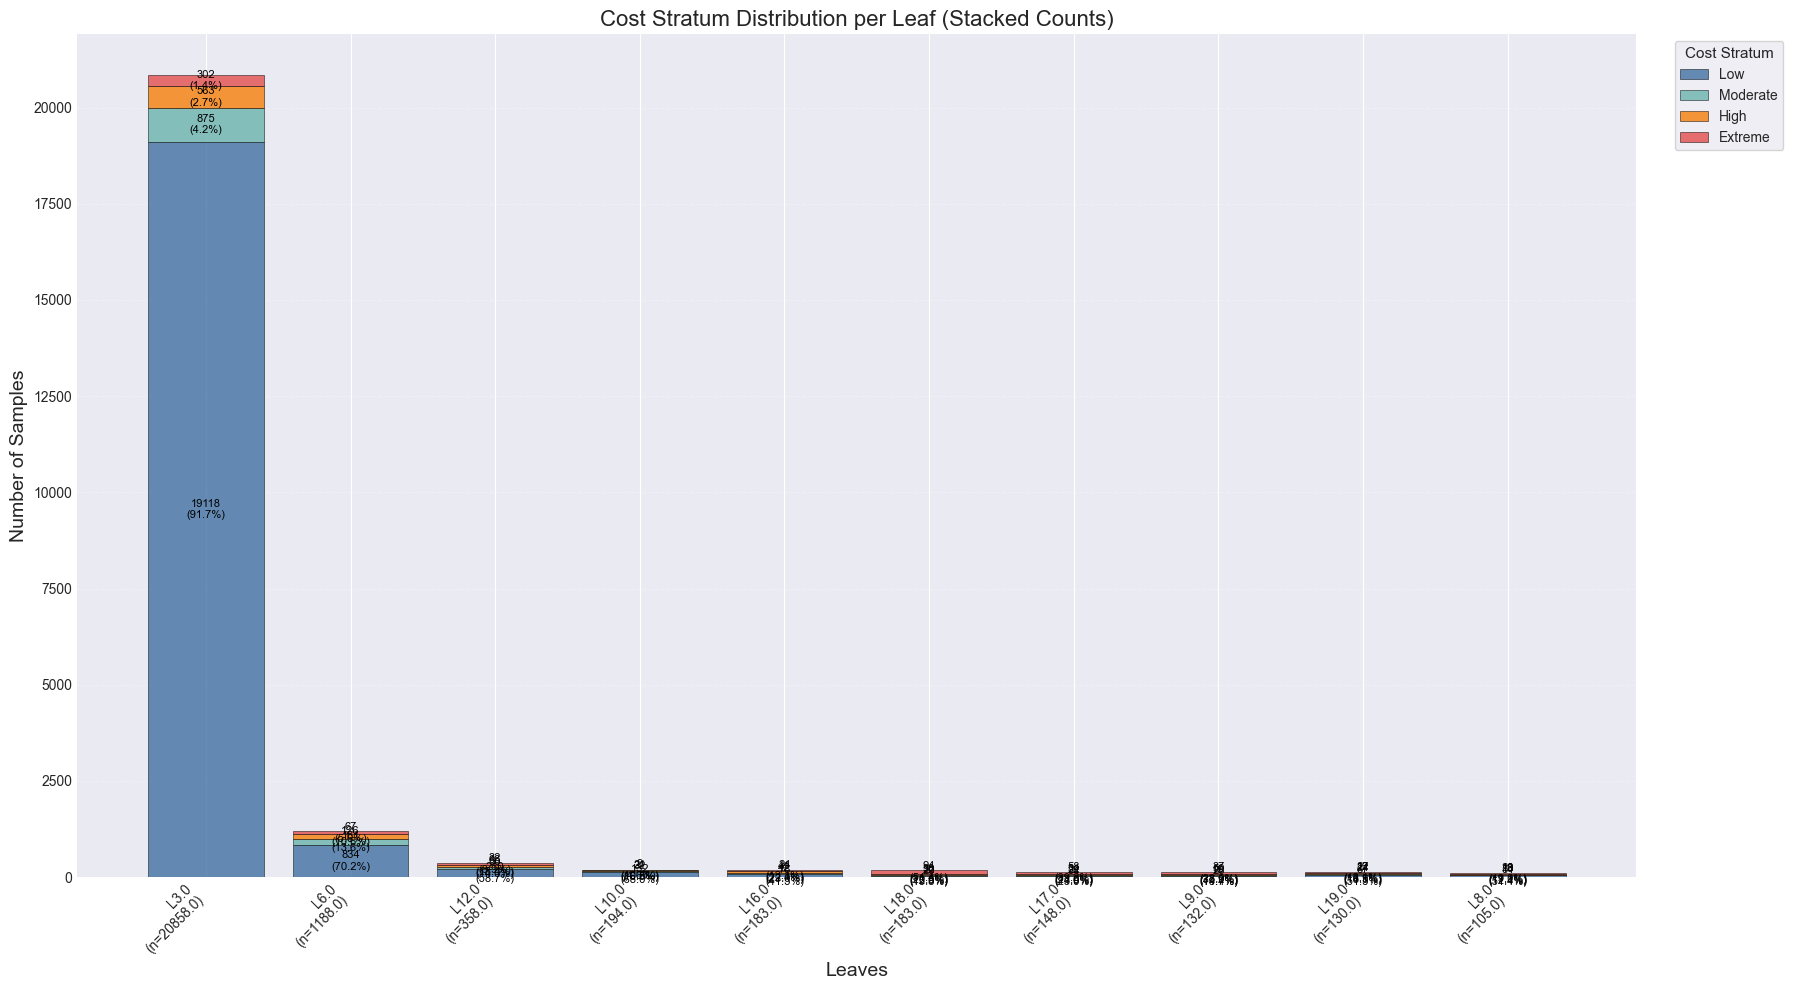


LEAF STRATUM SUMMARY
Overall class distribution across all leaves:
  Stratum 0 (Low): 20580 (87.7%)
  Stratum 1 (Moderate): 1260 (5.4%)
  Stratum 2 (High): 979 (4.2%)
  Stratum 3 (Extreme): 660 (2.8%)

Dominant stratum frequency among selected leaves:
  Stratum 0 (Low): 7 leaves (70.0%)
  Stratum 3 (Extreme): 2 leaves (20.0%)
  Stratum 2 (High): 1 leaves (10.0%)

Mean predicted vs actual rates (overall):
 Stratum    Label  Actual_Rate  Pred_Rate
       0      Low        0.877      0.980
       1 Moderate        0.054      0.000
       2     High        0.042      0.006
       3  Extreme        0.028      0.014


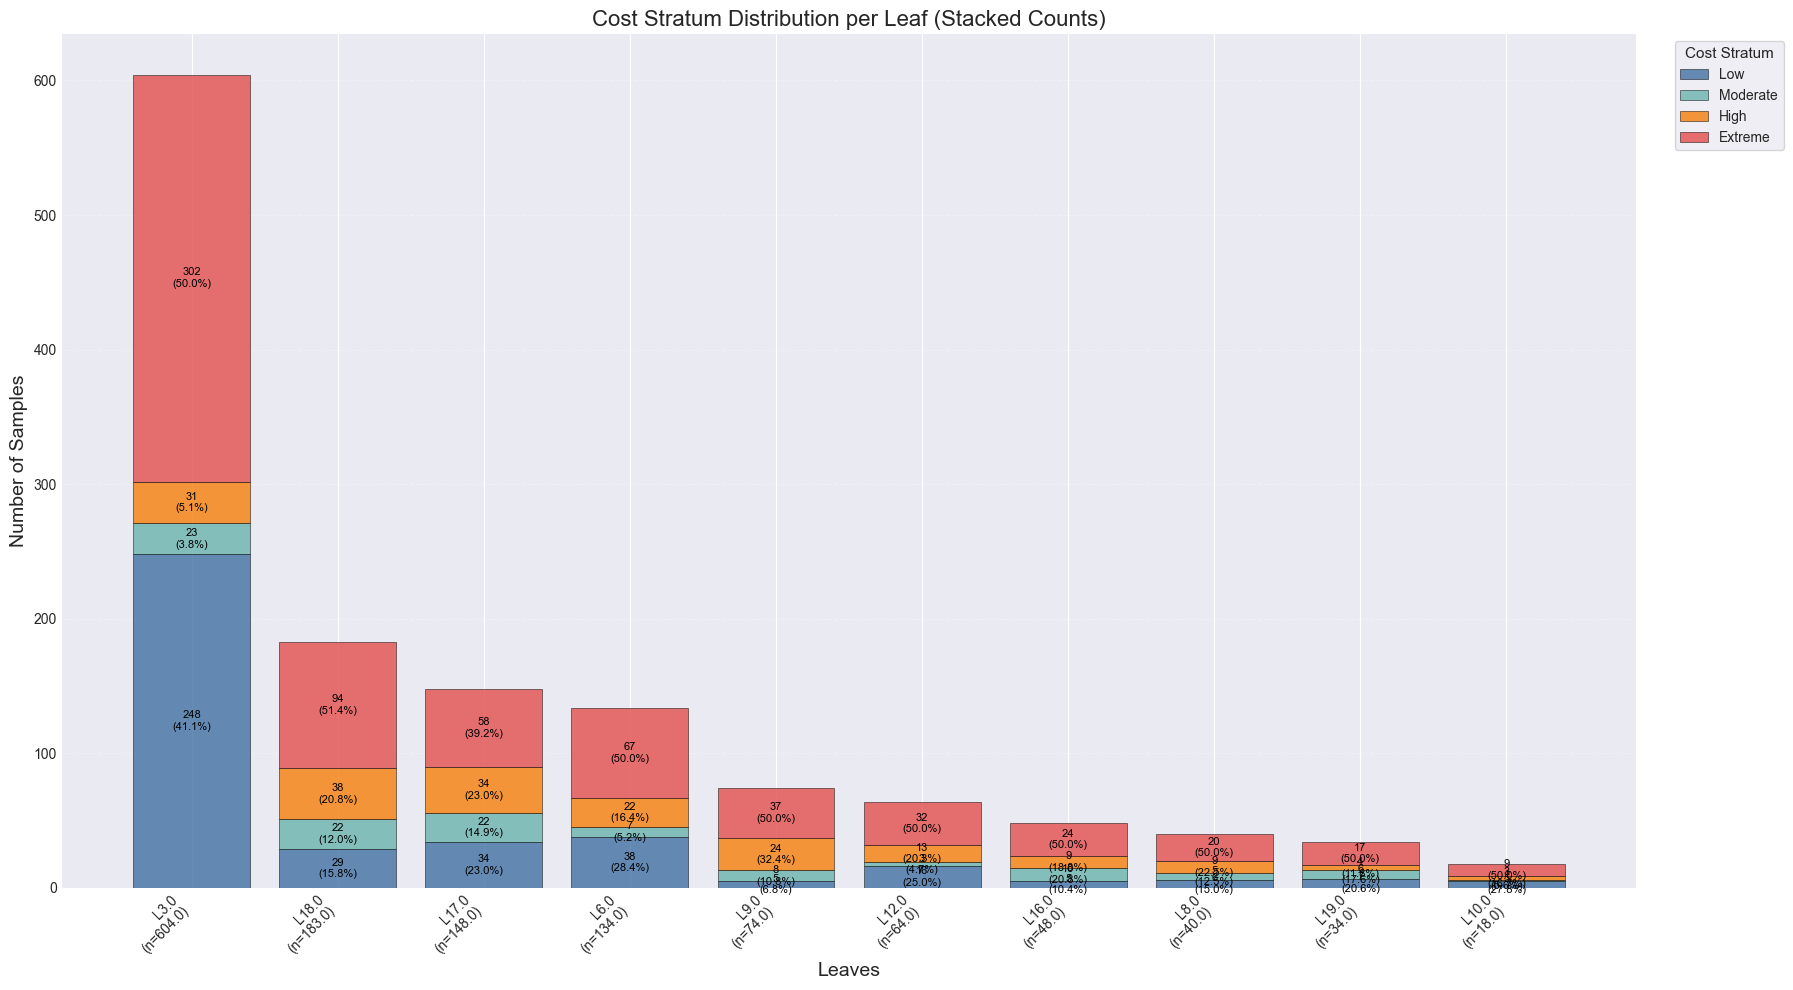


LEAF STRATUM SUMMARY
Overall class distribution across all leaves:
  Stratum 0 (Low): 393 (29.2%)
  Stratum 1 (Moderate): 107 (7.9%)
  Stratum 2 (High): 187 (13.9%)
  Stratum 3 (Extreme): 660 (49.0%)

Dominant stratum frequency among selected leaves:
  Stratum 3 (Extreme): 10 leaves (100.0%)

Mean predicted vs actual rates (overall):
 Stratum    Label  Actual_Rate  Pred_Rate
       0      Low        0.292      0.699
       1 Moderate        0.079      0.000
       2     High        0.139      0.055
       3  Extreme        0.490      0.246


In [18]:
import oct_leaf_analysis
importlib.reload(oct_leaf_analysis)
labels = {0: 'Low', 1: 'Moderate', 2: 'High', 3: 'Extreme'}
colors = {0: '#4C78A8', 1: '#72B7B2', 2: '#F58518', 3: '#E45756'}
leaf_stats_df = oct_leaf_analysis.visualize_leaf_cost_distributions_4class(
    df_M1,
    strata_labels=labels,
    strata_colors=colors
)

leaf_stats_df = oct_leaf_analysis.visualize_leaf_cost_distributions_4class(
    undersampled_training_data,
    strata_labels=labels,
    strata_colors=colors
)


# Model Comparisons

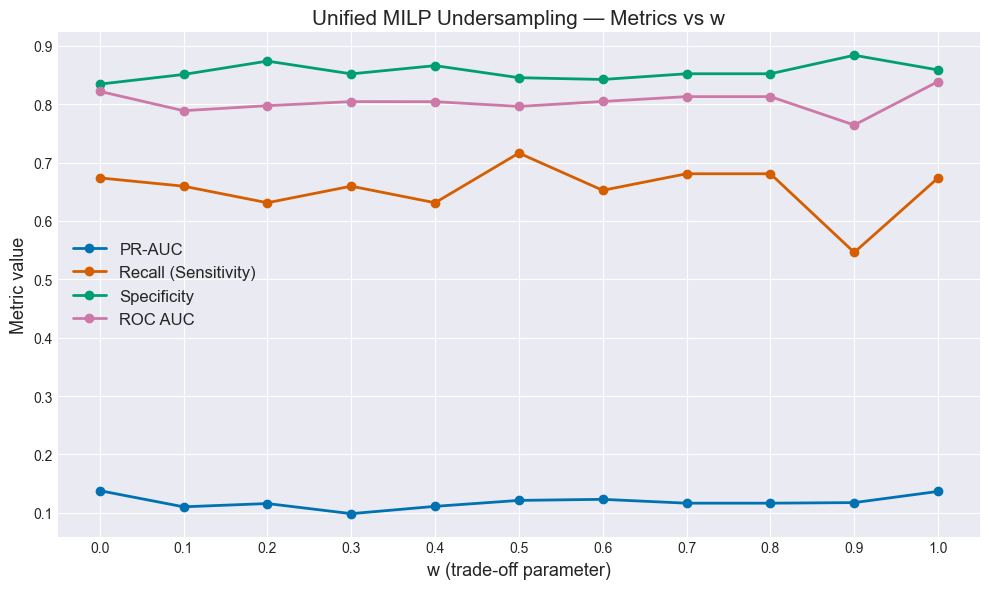

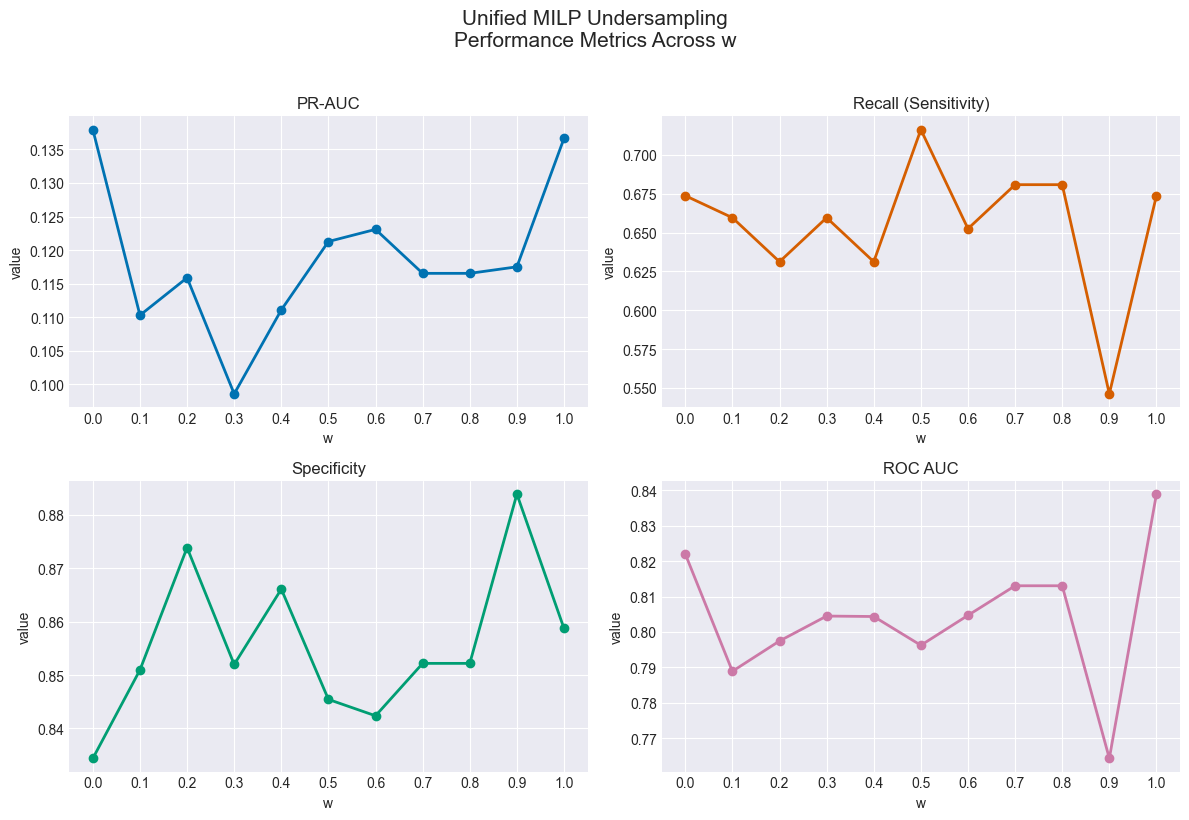

In [11]:
import re,os
import pickle

#results_dir = "./w_sweep_results_dispersion/"
# Regex to extract w value from filename "metrics_full_w_0.25.pkl"
pattern = re.compile(fr"metrics_full_w_([0-9.]+)\_seed{split_seed}.pkl")

records = []

# Load all pickle metric files
for fname in os.listdir(results_dir):
    m = pattern.match(fname)
    if not m:
        continue

    w = float(m.group(1))
    path = os.path.join(results_dir, fname)

    with open(path, "rb") as f:
        metrics = pickle.load(f)

    metrics = metrics.copy()      # avoid mutating original dict
    metrics["w"] = w

    # Remove leaf_metrics (big dataframe)
    if "leaf_metrics" in metrics:
        del metrics["leaf_metrics"]

    records.append(metrics)

# Create DataFrame sorted by w
df = pd.DataFrame(records).sort_values("w").reset_index(drop=True)
plt.style.use("seaborn-v0_8-darkgrid")

metrics_to_plot = ["pr_auc", "sensitivity", "specificity", "auc"]
titles = ["PR-AUC", "Recall (Sensitivity)", "Specificity", "ROC AUC"]
colors = ["#0072B2", "#D55E00", "#009E73", "#CC79A7"]

# ---------------------------
# Combined plot
# ---------------------------
plt.figure(figsize=(10, 6))
for metric, title, c in zip(metrics_to_plot, titles, colors):
    plt.plot(df["w"], df[metric], marker="o", linewidth=2, label=title, color=c)

plt.xlabel("w (trade-off parameter)", fontsize=13)
plt.ylabel("Metric value", fontsize=13)
plt.title("Unified MILP Undersampling — Metrics vs w", fontsize=15)
plt.legend(fontsize=12)
plt.xticks(df["w"])
plt.tight_layout()
plt.show()



# ---------------------------
# Separate subplot grid
# ---------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, metric, title, c in zip(axes, metrics_to_plot, titles, colors):
    ax.plot(df["w"], df[metric], marker="o", color=c, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("w")
    ax.set_ylabel("value")
    ax.set_xticks(df["w"])
    ax.grid(True)

fig.suptitle("Unified MILP Undersampling\nPerformance Metrics Across w", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


In [27]:
undersampled_training_data =  pd.read_csv(f"experiments_1016/prebalanced_matched_ratio_1.csv")


In [20]:
import model_IAI
importlib.reload(model_IAI)
from model_IAI import evaluate_binary_oct, finetune_oct

X_train_undersampled = undersampled_training_data[feature_cols]
y_train_undersampled = undersampled_training_data[target_col]
print(X_train_undersampled.shape)

minbuckets_M2=[150,200,300]
cps_M2=[0.00001,5e-5, 0.0001,5e-3]
depths_M2=[5,7]
balanced_model, balanced_params, results_balanced ,preprocessor, feature_names = finetune_oct(
    X_train_undersampled, y_train_undersampled,X_val, y_val,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS,
    depths=depths_M2,
    minbuckets=minbuckets_M2,
    cps=cps_M2
)

print("Best params:", balanced_params)
print("Balanced model: ", evaluate_binary_oct(balanced_model,X_test,y_test,preprocessor,feature_names))
balanced_model


(1347, 78)
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2017', 'quarterly_skewness_2017', 'quarterly_kurtosis_2017', 'quarterly_cv_2017', 'quarterly_max_2017', 'quart

Fitted OptimalTreeClassifier:
  1) Split: 2017Q4_ckd_cost < 0.2026
    2) Split: 2017Q4_ckd_cost < -0.4981
      3) Predict: 0 (62.46%), [218,131], 349 points, error 0.3754
      4) Split: 2017Q4_ckd_claims < -0.3483
        5) Predict: 1 (62.66%), [115,193], 308 points, error 0.3734
        6) Predict: 0 (62.98%), [245,144], 389 points, error 0.3702
    7) Predict: 1 (63.79%), [109,192], 301 points, error 0.3621

In [14]:
import model_IAI
importlib.reload(model_IAI)
from model_IAI import evaluate_binary_oct, finetune_oct
from imblearn.under_sampling import RandomUnderSampler
X = train_pd.drop(columns=[target_col])
y = train_pd[target_col]

ratio = 1.0   # majority should be 2x minority

minority_count = y.value_counts()[1]
target_majority = int(minority_count * ratio)

rus = RandomUnderSampler(
    sampling_strategy={0: target_majority, 1: minority_count},
    random_state=123
)

X_res, y_res = rus.fit_resample(X, y)

undersampled_rus = pd.concat([X_res, y_res], axis=1)
print(undersampled_rus['cost_stratum_2018'].value_counts())

print(X_res.shape)
rus_model, rus_params, results_rus,preprocessor, feature_names = finetune_oct(
    X_res[feature_cols], y_res,X_val, y_val,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS,
    depths=depths_M2,
    minbuckets=minbuckets_M2,
    cps=cps_M2
)

print("Best params:", rus_params)
print(results_rus)
rus_model


evaluate_binary_oct(rus_model,X_test,y_test,preprocessor,feature_names)

cost_stratum_2018
3    660
0    579
2     45
1     36
Name: count, dtype: int64
(1320, 95)
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2017', 'quarterly_skewness_201

{'auc': 0.8335885422784067,
 'pr_auc': np.float64(0.11744603774753402),
 'sensitivity': np.float64(0.7943262411347518),
 'specificity': np.float64(0.8311183806992435),
 'tp': np.int64(112),
 'fp': np.int64(826),
 'fn': np.int64(29),
 'tn': np.int64(4065),
 'leaf_metrics':    leaf_id     n  accuracy  precision  recall        f1
 3        7   536  0.145522   0.145522     1.0  0.254072
 2        6   402  0.084577   0.084577     1.0  0.155963
 0        2  2516  0.994436   0.000000     0.0  0.000000
 1        5  1578  0.990494   0.000000     0.0  0.000000}